# Modeling Investor Behaviour Using Historical Drawdowns

*Quant Lab · The Analytical Investor · Year 1, Month 6*

**Read the article:** [Modeling Investor Behaviour Using Historical Drawdowns](https://analytical-investor.blog/?p=1011)

Two investors, identical portfolios, 2,000 simulated 40-year histories. One holds; one sells after a 25% drawdown and buys back after a 20% rally. We measure what the panic costs.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
Simulate the paths, run both investors, and compare terminal wealth.

In [2]:
import numpy as np

rng = np.random.default_rng(7)

# ------------------------------------------------------------------
# 1. Simulate many 40-year monthly return paths (Student-t shocks)
# ------------------------------------------------------------------
n_paths, years = 2_000, 40
n_months = years * 12
mu_m, sig_m, dof = 0.07/12, 0.16/np.sqrt(12), 5

shocks = rng.standard_t(dof, (n_paths, n_months))
shocks *= sig_m / np.sqrt(dof/(dof-2))          # scale t to target vol
rets = mu_m + shocks                             # monthly returns

# ------------------------------------------------------------------
# 2. Investor A: buy-and-hold
# ------------------------------------------------------------------
wealth_hold = np.cumprod(1 + rets, axis=1)

# ------------------------------------------------------------------
# 3. Investor B: panic rule
#    - sells to cash after drawdown breaches -25%
#    - re-enters after market rises 20% off its low ("feels safe")
# ------------------------------------------------------------------
def panic_path(r, dd_sell=-0.25, rally_buy=0.20):
    n = len(r)
    wealth, invested = np.empty(n), True
    w, index, peak, trough = 1.0, 1.0, 1.0, 1.0
    for t in range(n):
        index *= (1 + r[t])                      # the market itself
        peak = max(peak, index)
        if invested:
            w *= (1 + r[t])
            if index/peak - 1 <= dd_sell:        # capitulation
                invested, trough = False, index
        else:
            trough = min(trough, index)
            if index/trough - 1 >= rally_buy:    # confidence returns
                invested = True
        wealth[t] = w
    return wealth

wealth_panic = np.array([panic_path(r) for r in rets])

# ------------------------------------------------------------------
# 4. Compare outcomes
# ------------------------------------------------------------------
tw_hold, tw_panic = wealth_hold[:, -1], wealth_panic[:, -1]
ratio = tw_panic / tw_hold

print(f"Median terminal wealth  — hold : {np.median(tw_hold):8.1f}")
print(f"Median terminal wealth  — panic: {np.median(tw_panic):8.1f}")
print(f"Median panic/hold ratio        : {np.median(ratio):.2f}")
print(f"Paths where panicking won      : {(ratio > 1).mean():.1%}")

ann_gap = (np.median(tw_hold)/np.median(tw_panic))**(1/years) - 1
print(f"Annualized cost of panic rule  : {ann_gap:.2%} per year")

Median terminal wealth  — hold :     10.0
Median terminal wealth  — panic:      5.3
Median panic/hold ratio        : 0.55
Paths where panicking won      : 4.5%
Annualized cost of panic rule  : 1.61% per year


### Where the panicker ends up
Left: terminal wealth ratio (panic / hold) across all paths; anything left of 1.0 is money lost to the rule. Right: median wealth over time.

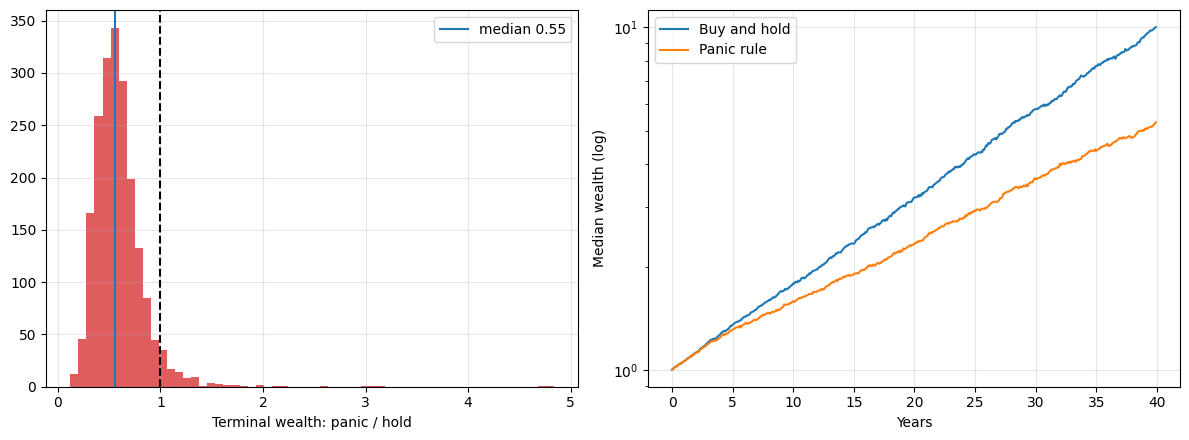

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.hist(ratio, bins=60, color="tab:red", alpha=0.75)
a1.axvline(1.0, color="k", ls="--"); a1.axvline(np.median(ratio), color="tab:blue", label=f"median {np.median(ratio):.2f}")
a1.set_xlabel("Terminal wealth: panic / hold"); a1.legend()
t = np.arange(n_months) / 12
a2.plot(t, np.median(wealth_hold, axis=0), label="Buy and hold")
a2.plot(t, np.median(wealth_panic, axis=0), label="Panic rule")
a2.set_yscale("log"); a2.set_xlabel("Years"); a2.set_ylabel("Median wealth (log)"); a2.legend()
plt.tight_layout(); plt.show()

## The same thing with the toolkit
The model above lives in the `analytical_investor` package, tested and reusable.

In [4]:
from analytical_investor import behavior

# Try your own thresholds: when would *you* sell, and when would you buy back?
for dd, rally in [(-0.15, 0.10), (-0.25, 0.20), (-0.35, 0.30)]:
    out = behavior.behavior_gap(rets[:500], years=years, dd_sell=dd, rally_buy=rally)
    print(f"sell at {dd:.0%}, rebuy after +{rally:.0%}: annual cost {out['annual_cost']:.2%}")

sell at -15%, rebuy after +10%: annual cost 2.50%
sell at -25%, rebuy after +20%: annual cost 1.69%


sell at -35%, rebuy after +30%: annual cost 0.78%


---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=1011).